**Dataset:** [Medical Cost Personal Datasets - Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## About the Dataset

This project uses the **Medical Cost Personal Dataset**, originally published on Kaggle: [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance). The dataset contains demographic and health-related information for 1,338 individuals in the United States, along with the medical insurance charges billed to each of them. The goal of this analysis is to explore which factors most strongly influence insurance costs, and to build regression models capable of predicting `charges` based on personal attributes such as age, BMI, and smoking status.

### Column Descriptions

| Column | Description | Type |
|---|---|---|
| `age` | Age of the primary beneficiary | Numeric |
| `sex` | Gender of the policyholder (`male` / `female`) | Categorical |
| `bmi` | Body Mass Index, a measure of body fat based on height and weight | Numeric |
| `children` | Number of children/dependents covered by the insurance | Numeric |
| `smoker` | Whether the person smokes (`yes` / `no`) | Categorical |
| `region` | Residential area in the US (`northeast`, `northwest`, `southeast`, `southwest`) | Categorical |
| `charges` | Individual medical costs billed by health insurance (**target variable**) | Numeric |

The dataset contains 1,338 records (1,337 after removing one duplicate row), with no missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
print("\nValores ausentes por coluna:\n", df.isna().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Valores ausentes por coluna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Linhas duplicadas: 1


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
# Ver a(s) linha(s) duplicada(s)
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [4]:
df = df.drop_duplicates()
print("Novo total de linhas:", df.shape[0])

Novo total de linhas: 1337


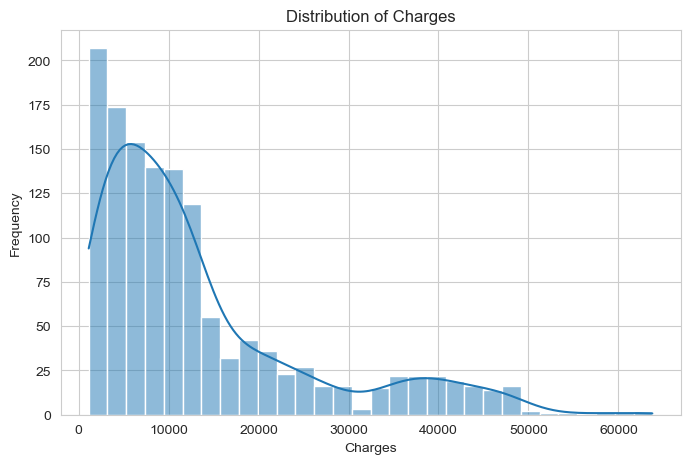

Skewness: 1.5153909108403483


In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True, bins=30)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

print("Skewness:", df['charges'].skew())

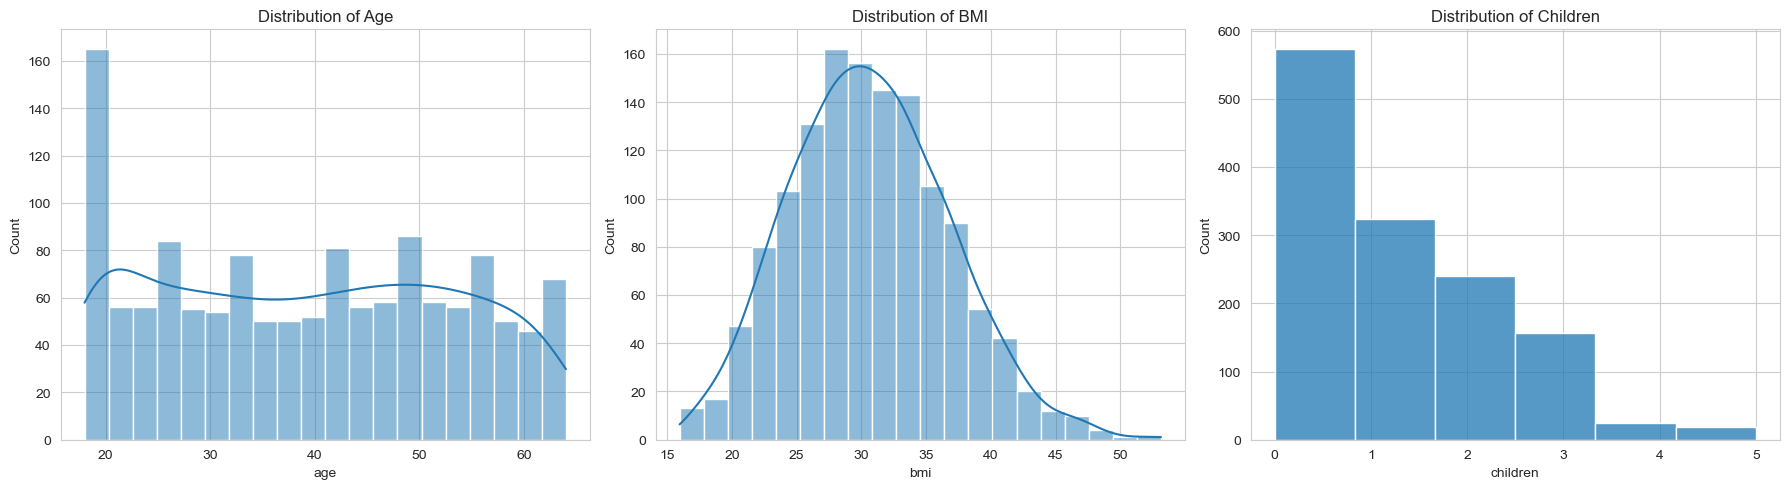

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['age'], kde=True, bins=20, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['bmi'], kde=True, bins=20, ax=axes[1])
axes[1].set_title('Distribution of BMI')

sns.histplot(df['children'], kde=False, bins=6, ax=axes[2])
axes[2].set_title('Distribution of Children')

plt.tight_layout()
plt.show()

Age is fairly uniformly distributed between 18 and 64, with a slight concentration at the youngest ages. BMI follows an approximately normal distribution centered around 30. The number of children is highly right-skewed, with most policyholders having zero dependents.

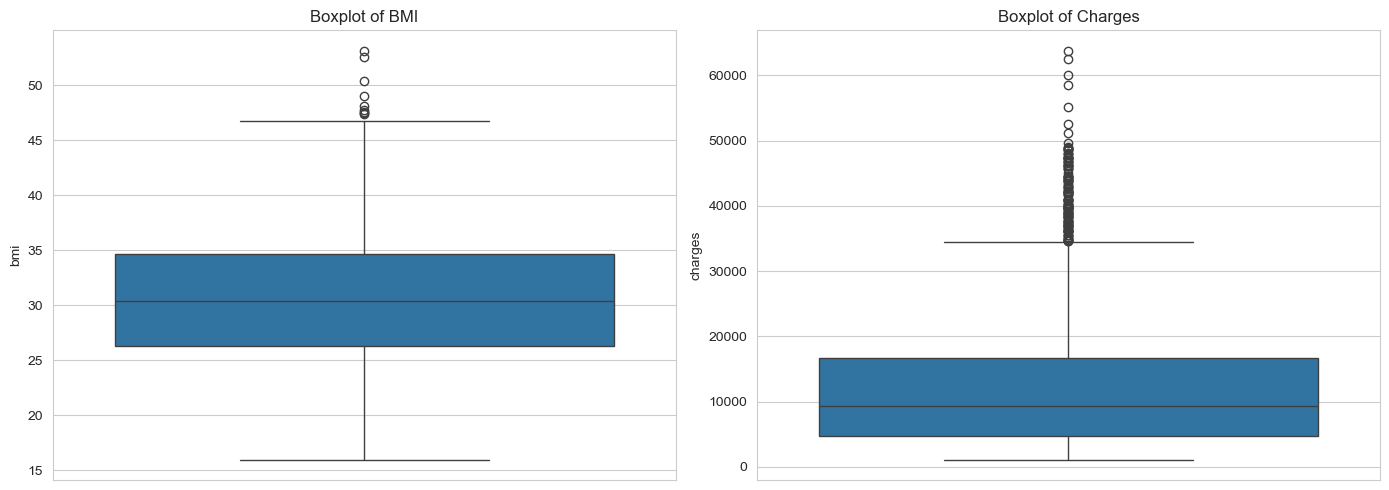

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(y=df['bmi'], ax=axes[0])
axes[0].set_title('Boxplot of BMI')

sns.boxplot(y=df['charges'], ax=axes[1])
axes[1].set_title('Boxplot of Charges')

plt.tight_layout()
plt.show()

In [8]:
def count_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers out of {len(df)} rows "
          f"({len(outliers)/len(df)*100:.2f}%)")
    print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]\n")
    return outliers

bmi_outliers = count_outliers_iqr('bmi')
charges_outliers = count_outliers_iqr('charges')

bmi: 9 outliers out of 1337 rows (0.67%)
Bounds: [13.67, 47.32]

charges: 139 outliers out of 1337 rows (10.40%)
Bounds: [-13120.72, 34524.78]



Using the IQR method, BMI has very few outliers (0.67%), consistent with naturally occurring high-BMI individuals. Charges has a notably higher outlier rate (10.40%), with no negative lower bound being meaningful (charges cannot be negative). Rather than removing these points, we will investigate whether they correspond to a meaningful subgroup (e.g., smokers) before deciding how to handle them in modeling.

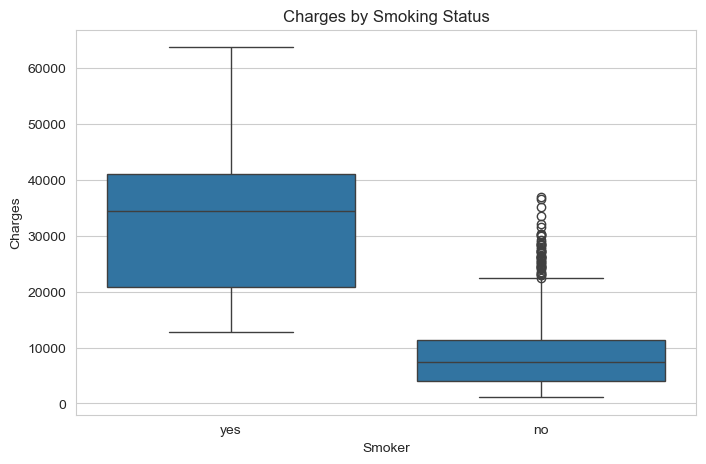

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

print(df.groupby('smoker')['charges'].mean())

Smoking status has a dramatic effect on insurance charges: smokers pay on average $32,050, nearly 4 times more than non-smokers ($8,441). This explains the bimodal shape and most of the "outliers" seen in the charges distribution — they are not data errors but a real and highly predictive subgroup. This confirms that smoker will likely be one of the strongest predictors in our regression models.Smoking status has a dramatic effect on insurance charges: smokers pay on average $32,050, nearly 4 times more than non-smokers ($8,441). This explains the bimodal shape and most of the "outliers" seen in the charges distribution — they are not data errors but a real and highly predictive subgroup. This confirms that smoker will likely be one of the strongest predictors in our regression models.

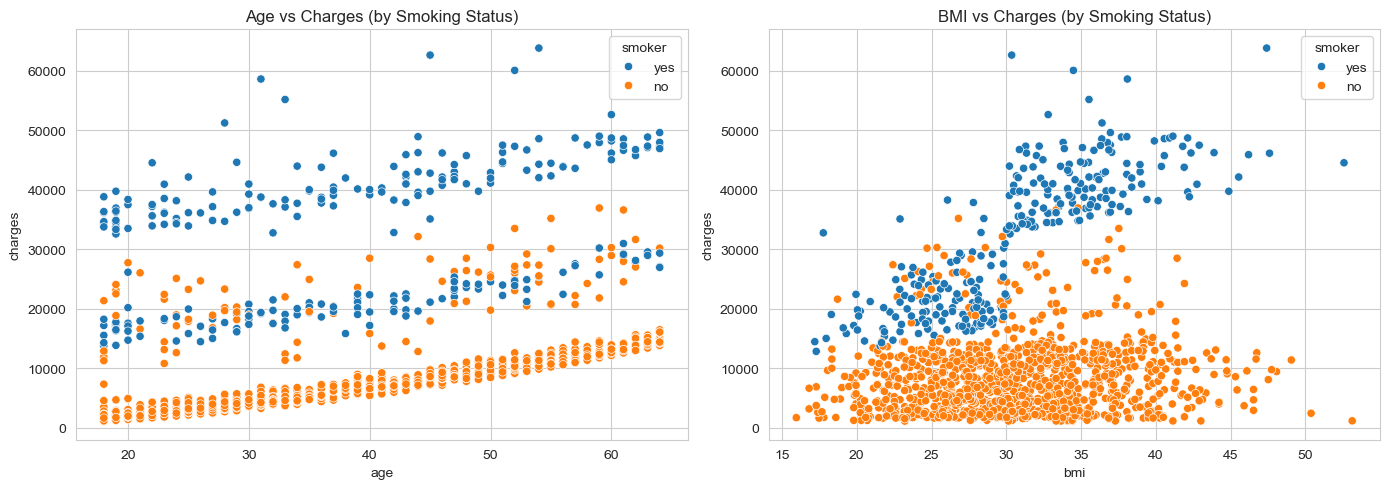

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0])
axes[0].set_title('Age vs Charges (by Smoking Status)')

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1])
axes[1].set_title('BMI vs Charges (by Smoking Status)')

plt.tight_layout()
plt.show()

Age shows a positive but noisy relationship with charges across three distinct bands. BMI reveals a clear interaction effect: among smokers, charges increase sharply once BMI crosses ~30 (obesity threshold), splitting smokers into a lower-cost and a much higher-cost group. Among non-smokers, BMI has a comparatively small effect. This interaction between smoker and bmi will be important to capture in our regression models, especially the polynomial one.

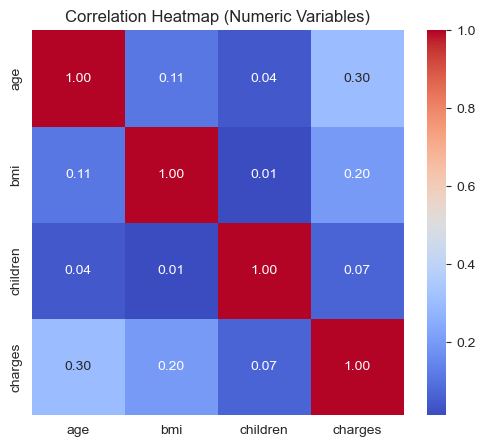

In [11]:
plt.figure(figsize=(6,5))
corr = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Variables)')
plt.show()

Among numeric variables, age has the strongest linear correlation with charges (0.30), followed by bmi (0.20); children shows almost no correlation (0.07). Note that this heatmap only captures numeric variables — it does not reflect the strong effect of the categorical variable smoker, which we already showed has a far greater impact on charges than any numeric variable alone. This highlights the importance of including categorical features in our models.

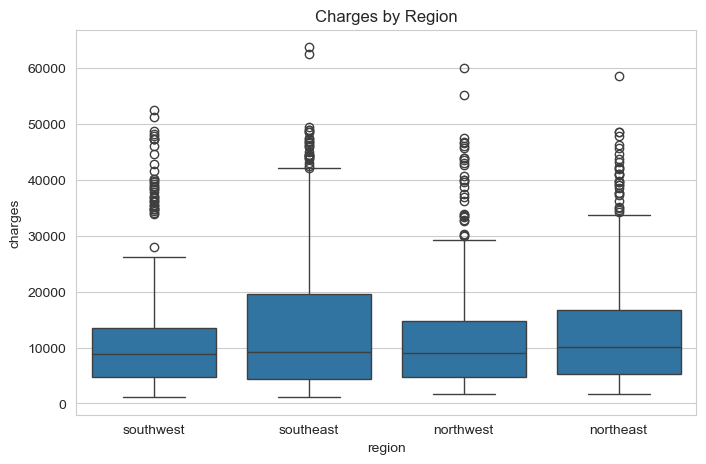

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

print(df.groupby('region')['charges'].mean())

Charges vary modestly by region, ranging from $12,347 (southwest) to $14,735 (southeast). The effect of region is much smaller than that of smoking status, and high-cost outliers appear across all regions — confirming that smoking, not geography, is the primary driver of extreme charges.

In [13]:
# Convert categorical variables into numeric (one-hot encoding)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [14]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1069, 8)
Test set size: (268, 8)


In [15]:
# Single-variable Linear Regression using 'age'
X_train_single = X_train[['age']]
X_test_single = X_test[['age']]

lr_single = LinearRegression()
lr_single.fit(X_train_single, y_train)

y_pred_single = lr_single.predict(X_test_single)

print("Coefficient:", lr_single.coef_[0])
print("Intercept:", lr_single.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_single)))
print("MAE:", mean_absolute_error(y_test, y_pred_single))
print("R²:", r2_score(y_test, y_pred_single))

Coefficient: 242.25815190122512
Intercept: 3534.09173307106
RMSE: 12894.779883028823
MAE: 9657.78934976123
R²: 0.09513000782072023


A single-variable linear regression using only age achieves R² = 0.095, meaning it explains less than 10% of the variance in charges. This confirms our EDA finding that age alone is a weak predictor; the smoker status is likely to contribute far more explanatory power, which we will test next.

In [16]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

y_pred_multi = lr_multi.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("R²:", r2_score(y_test, y_pred_multi))

# Show coefficients
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_multi.coef_})
coef_df.sort_values(by='Coefficient', ascending=False)

RMSE: 5956.342894363589
MAE: 4177.04556103632
R²: 0.8069287081198011


,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


Adding all available features dramatically improves performance: R² rises from 0.095 (age only) to 0.807, and RMSE drops from ~$12,895 to ~$5,956. As expected from the EDA, smoker_yes has by far the largest coefficient (+$23,078), confirming it as the dominant predictor. children, bmi, and age contribute positively but modestly, while sex and region have minimal effect.

In [17]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_single = poly.fit_transform(X_train[['age']])
X_test_poly_single = poly.transform(X_test[['age']])

poly_single = LinearRegression()
poly_single.fit(X_train_poly_single, y_train)

y_pred_poly_single = poly_single.predict(X_test_poly_single)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly_single)))
print("MAE:", mean_absolute_error(y_test, y_pred_poly_single))
print("R²:", r2_score(y_test, y_pred_poly_single))

RMSE: 12958.263747140816
MAE: 9720.739486586126
R²: 0.08619832375759173


A polynomial regression (degree 2) using only age performs almost identically to the simple linear model (R² = 0.086 vs 0.095), indicating that the relationship between age and charges is close to linear and doesn't benefit much from a quadratic term on its own.

In [18]:
poly_multi_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_multi_transformer.fit_transform(X_train)
X_test_poly = poly_multi_transformer.transform(X_test)

poly_multi = LinearRegression()
poly_multi.fit(X_train_poly, y_train)

y_pred_poly_multi = poly_multi.predict(X_test_poly)

print("Number of features after transformation:", X_train_poly.shape[1])
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly_multi)))
print("MAE:", mean_absolute_error(y_test, y_pred_poly_multi))
print("R²:", r2_score(y_test, y_pred_poly_multi))

Number of features after transformation: 44
RMSE: 4646.056793068941
MAE: 2867.317439475312
R²: 0.8825298972468516


The multi-variable polynomial model (degree 2, 44 features after expansion) substantially outperforms all previous models: R² = 0.883, RMSE ≈ $4,646, MAE ≈ $2,867. This confirms the interaction effect observed in the EDA — particularly between bmi and smoker_yes — where the impact of BMI on charges is far stronger for smokers than non-smokers. Capturing this interaction is key to the improved performance.

In [19]:
# Ridge - single variable (age)
ridge_single = Ridge(alpha=1.0)
ridge_single.fit(X_train_single, y_train)
y_pred_ridge_single = ridge_single.predict(X_test_single)

print("--- Ridge (single variable: age) ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge_single)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge_single))
print("R²:", r2_score(y_test, y_pred_ridge_single))

# Ridge - multi-variable (all features)
ridge_multi = Ridge(alpha=1.0)
ridge_multi.fit(X_train, y_train)
y_pred_ridge_multi = ridge_multi.predict(X_test)

print("\n--- Ridge (multi-variable) ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge_multi)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge_multi))
print("R²:", r2_score(y_test, y_pred_ridge_multi))

--- Ridge (single variable: age) ---
RMSE: 12894.7812071219
MAE: 9657.7898525196
R²: 0.09512982198859843

--- Ridge (multi-variable) ---
RMSE: 5971.338292131435
MAE: 4194.00957732449
R²: 0.8059553507246431


With default alpha=1.0, Ridge regression performs almost identically to ordinary linear regression on both the single-variable and multi-variable versions. This is expected, since alpha=1.0 applies only a mild penalty. The real value of Ridge will appear when we apply it to the high-dimensional polynomial feature set (44 features), where regularization should help control overfitting. We will tune alpha via grid search next.

In [20]:
ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly, y_train)
y_pred_ridge_poly = ridge_poly.predict(X_test_poly)

print("--- Ridge on Polynomial Features (alpha=1.0) ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge_poly))
print("R²:", r2_score(y_test, y_pred_ridge_poly))

--- Ridge on Polynomial Features (alpha=1.0) ---
RMSE: 4641.28395677641
MAE: 2867.1106092506525
R²: 0.8827711244260649


Applying Ridge regularization to the 44 polynomial features yields a slight improvement over plain polynomial regression (R² = 0.8828 vs 0.883, RMSE ≈ $4,641 vs $4,646), suggesting mild overfitting is being controlled. To find the optimal regularization strength, we now perform a grid search over a range of alpha values.

In [21]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 500, 1000]}

grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5
)

grid_search.fit(X_train_poly, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

# Evaluate the best model on the test set
best_ridge = grid_search.best_estimator_
y_pred_best = best_ridge.predict(X_test_poly)

print("\n--- Best Ridge on Test Set ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("R²:", r2_score(y_test, y_pred_best))

Best alpha: {'alpha': 1}
Best CV RMSE: 4909.0216796716795

--- Best Ridge on Test Set ---
RMSE: 4641.28395677641
MAE: 2867.1106092506525
R²: 0.8827711244260649


A grid search across alpha values from 0.001 to 1000, using 5-fold cross-validation on the polynomial feature set, identified alpha=1 as optimal (best CV RMSE ≈ $4,909). On the held-out test set, this model achieves RMSE ≈ $4,641, MAE ≈ $2,867, and R² ≈ 0.883 — matching our earlier informal Ridge result. This indicates that, for this feature set and dataset size, a moderate regularization strength already balances bias and variance well; stronger regularization tends to underfit, while weaker regularization offers no meaningful benefit since overfitting was already mild.

In [22]:
results = pd.DataFrame({
    'Model': [
        'Linear (age only)',
        'Linear (all features)',
        'Polynomial deg2 (age only)',
        'Polynomial deg2 (all features)',
        'Ridge alpha=1 (age only)',
        'Ridge alpha=1 (all features)',
        'Ridge alpha=1 (polynomial features)',
        'Ridge - Grid Search Best (polynomial features)'
    ],
    'RMSE': [12894.78, 5956.34, 12958.26, 4646.06, 12894.78, 5971.34, 4641.28, 4641.28],
    'MAE': [9657.79, 4177.05, 9720.74, 2867.32, 9657.79, 4194.01, 2867.11, 2867.11],
    'R2': [0.0951, 0.8069, 0.0862, 0.8825, 0.0951, 0.8060, 0.8828, 0.8828]
})

results.sort_values(by='R2', ascending=False)

,Model,RMSE,MAE,R2
6,Ridge alpha=1 (polynomial features),4641.28,2867.11,0.8828
7,Ridge - Grid Search Best (polynomial features),4641.28,2867.11,0.8828
3,Polynomial deg2 (all features),4646.06,2867.32,0.8825
1,Linear (all features),5956.34,4177.05,0.8069
5,Ridge alpha=1 (all features),5971.34,4194.01,0.8060
0,Linear (age only),12894.78,9657.79,0.0951
4,Ridge alpha=1 (age only),12894.78,9657.79,0.0951
2,Polynomial deg2 (age only),12958.26,9720.74,0.0862


## Conclusion

This project analyzed the Medical Cost Personal Dataset to understand and predict individual medical insurance charges. Key findings from the EDA showed that **smoking status** is by far the strongest driver of cost — smokers pay nearly 4x more on average than non-smokers ($32,050 vs $8,441) — with a strong interaction effect between `smoker` and `bmi`: charges rise sharply for smokers once BMI exceeds ~30.

Among the regression models tested, simple single-variable models (using only `age`) performed poorly (R² ≈ 0.10), confirming that no single numeric feature is sufficient. Multi-variable models performed dramatically better, and the **polynomial regression with all features (degree 2)** achieved the best overall test performance (R² ≈ 0.883, RMSE ≈ $4,646), driven by its ability to capture the `bmi` × `smoker` interaction.

Ridge regression, after grid search tuning (best alpha = 1), matched the polynomial model's performance (R² ≈ 0.883) while providing protection against overfitting on the 44-feature polynomial set — making it the preferred final model for generalization to new data.

**Limitations & Future Work:** Region and sex had minimal predictive value and could potentially be dropped in future iterations. Exploring higher-degree polynomial terms, tree-based models (Random Forest, Gradient Boosting), or explicit interaction terms (e.g., `bmi` × `smoker`) could further improve performance.